# SAJAX — Quick Start Example

This notebook shows the minimal steps to simulate a stellar light curve with a single active region using SAJAX.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sajax import compute_light_curve

## 1. Define the wavelength grid and spectra

We use flat spectra here for simplicity. In practice you would load real stellar spectra.

In [2]:
wavelength = np.linspace(0.5, 2.5, 50, dtype=np.float32)  # microns
flux_quiet   = np.ones_like(wavelength)                      # unarted photosphere
flux_active  = np.full_like(wavelength, 0.7)                 # cooler ar (70% of photosphere)

## 2. Set stellar parameters

In [3]:
params = dict(
    u1       = 0.3,   # limb darkening coefficient 1
    u2       = 0.1,   # limb darkening coefficient 2
    inc_star = 90.0,  # stellar inclination in degrees (90 = equator-on)
)

## 3. Run the light curve computation

In [4]:
phases = np.linspace(0, 360, 50, endpoint=False)  # one full stellar rotation

result = compute_light_curve(
    wavelength        = wavelength,
    flux_quiet          = flux_quiet,
    flux_active         = flux_active,
    params            = params,
    ar_lat          = [20.0],   # latitude in degrees
    ar_long         = [0.0],    # longitude in degrees
    ar_size         = [15.0],   # angular radius in degrees
    phases_rot        = phases,
    stellar_grid_size = 100,      # stellar radius in pixels
    ve                = 2.0,      # equatorial velocity in km/s
    ldc_mode          = "multi-color",
)

print("Light curve shape :", result["lc"].shape)
print("Epsilon shape     :", result["epsilon"].shape)
print("Star maps shape   :", result["star_maps"].shape)

build_model: single-wavelength LDCs — repeating scalar u1/u2 across all wavelengths.
Light curve shape : (50,)
Epsilon shape     : (50, 50)
Star maps shape   : (50, 201, 201)


## 4. Plot the light curve

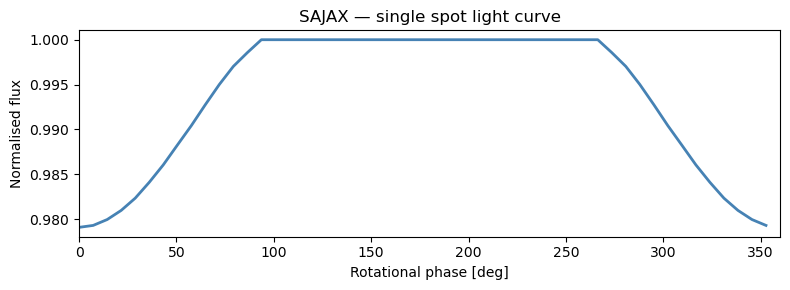

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(phases, result["lc"], color="steelblue", lw=2)
ax.set_xlabel("Rotational phase [deg]")
ax.set_ylabel("Normalised flux")
ax.set_title("SAJAX — single active region light curve")
ax.set_xlim(0, 360)
plt.tight_layout()
plt.show()

## 5. Plot a stellar map at a chosen phase

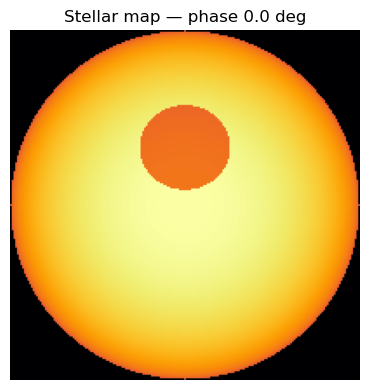

In [6]:
phase_idx = 0   # change this to inspect other phases

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(
    result["star_maps"][phase_idx],
    origin="lower",
    cmap="inferno",
)
ax.set_title(f"Stellar map — phase {phases[phase_idx]:.1f} deg")
ax.axis("off")
plt.tight_layout()
plt.show()